### Required Try-It Activity 14.1: Grid Searching Decision Trees 

This try-it focuses on performing a grid search with a `DecisionTreeClassifier`.  As mentioned in the lectures, the grid search for a tree model can get large very easily. In addition to using `GridSearchCV`, scikitlearn implements additional tools that can save energy and offer alternatives to the brute force exhaustive search.  Below, you will compare the performance of some of these alternatives and discuss the time these searches take.  Note that this will be in large part determined by your personal computing power however the relative speed of the searches should be consistent.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time as time

from sklearn.experimental import enable_halving_search_cv
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, HalvingGridSearchCV, HalvingRandomSearchCV
from sklearn.preprocessing import LabelEncoder

In [2]:
data = pd.read_csv('data/Whickham.txt')
data.head()

,outcome,smoker,age
0,Alive,Yes,23
1,Alive,Yes,18
2,Dead,Yes,71
3,Alive,No,67
4,Alive,No,64


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1314 entries, 0 to 1313
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   outcome  1314 non-null   object
 1   smoker   1314 non-null   object
 2   age      1314 non-null   int64 
dtypes: int64(1), object(2)
memory usage: 30.9+ KB


In [4]:
le = LabelEncoder()
data['outcome'] = le.fit_transform(data['outcome'])
data['smoker'] = le.fit_transform(data['smoker'])

X_train, X_test, y_train, y_test = train_test_split(data.drop('outcome', axis=1), data['outcome'], test_size=0.2, random_state=42)

In [5]:
params = {'max_depth': [1, 4, 8, 16, 32, 64],
        'min_samples_split': [None, 2, 4, 8],
        'criterion': ['gini', 'entropy'],
        'min_samples_leaf': [1, 2, 4, 8]
         }

In [6]:
dtree = DecisionTreeClassifier()

### Comparing Grid Searches

Below, explore the four grid search options using the same parameter selections for the `DecisionTreeClassifier`. All of the grid searching tools have a `.cv_results_` attribute after fitting that contains information after fitting including time.  Use this to compare the time of each search and discuss what you believe the "best" approach to identifying the hyperparameters of the model are between:

- `GridSearchCV`
- `RandomizedSearchCV`
- `HalvingGridSearchCV`
- `HalvingRandomSearchCV`

Share your results in a plot comparing the different times for searching across the different parameters as well as the score of the different estimators that resulted from the grid search.  

In [7]:
grid1 = GridSearchCV(dtree, param_grid=params)

t1_grid1 = time.time()
grid1.fit(X_train, y_train)
t2_grid1 = time.time()

/Users/angel/Workspace/pc_ml_ai/.venv/lib/python3.13/site-packages/sklearn/model_selection/_validation.py:490: FitFailedWarning: 
240 fits failed out of a total of 960.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
240 fits failed with the following error:
Traceback (most recent call last):
  File "/Users/angel/Workspace/pc_ml_ai/.venv/lib/python3.13/site-packages/sklearn/model_selection/_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/angel/Workspace/pc_ml_ai/.venv/lib/python3.13/site-packages/sklearn/base.py", line 1329, in wrapper
    estimator._validate_params()
    ~~~~~~~~~~~~~~~~~~~~~~~~~~^^
  File "/Users/angel/Workspa

In [8]:
grid2 = RandomizedSearchCV(dtree, param_distributions=params)

t1_grid2 = time.time()
grid2.fit(X_train, y_train)
t2_grid2 = time.time()

/Users/angel/Workspace/pc_ml_ai/.venv/lib/python3.13/site-packages/sklearn/model_selection/_validation.py:490: FitFailedWarning: 
15 fits failed out of a total of 50.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
15 fits failed with the following error:
Traceback (most recent call last):
  File "/Users/angel/Workspace/pc_ml_ai/.venv/lib/python3.13/site-packages/sklearn/model_selection/_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/angel/Workspace/pc_ml_ai/.venv/lib/python3.13/site-packages/sklearn/base.py", line 1329, in wrapper
    estimator._validate_params()
    ~~~~~~~~~~~~~~~~~~~~~~~~~~^^
  File "/Users/angel/Workspace/

In [9]:
grid3 = HalvingGridSearchCV(dtree, param_grid=params)

t1_grid3 = time.time()
grid3.fit(X_train, y_train)
t2_grid3 = time.time()

/Users/angel/Workspace/pc_ml_ai/.venv/lib/python3.13/site-packages/sklearn/model_selection/_validation.py:490: FitFailedWarning: 
240 fits failed out of a total of 960.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
240 fits failed with the following error:
Traceback (most recent call last):
  File "/Users/angel/Workspace/pc_ml_ai/.venv/lib/python3.13/site-packages/sklearn/model_selection/_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/angel/Workspace/pc_ml_ai/.venv/lib/python3.13/site-packages/sklearn/base.py", line 1329, in wrapper
    estimator._validate_params()
    ~~~~~~~~~~~~~~~~~~~~~~~~~~^^
  File "/Users/angel/Workspa

In [10]:
grid4 = HalvingRandomSearchCV(dtree, param_distributions=params)

t1_grid4 = time.time()
grid4.fit(X_train, y_train)
t2_grid4 = time.time()

/Users/angel/Workspace/pc_ml_ai/.venv/lib/python3.13/site-packages/sklearn/model_selection/_validation.py:490: FitFailedWarning: 
75 fits failed out of a total of 260.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
75 fits failed with the following error:
Traceback (most recent call last):
  File "/Users/angel/Workspace/pc_ml_ai/.venv/lib/python3.13/site-packages/sklearn/model_selection/_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/angel/Workspace/pc_ml_ai/.venv/lib/python3.13/site-packages/sklearn/base.py", line 1329, in wrapper
    estimator._validate_params()
    ~~~~~~~~~~~~~~~~~~~~~~~~~~^^
  File "/Users/angel/Workspace

In [ ]:
results = {
    'GridSearchCV': {
        'time': t2_grid1 - t1_grid1,
        'score': grid1.best_score_,
        'params': grid1.best_params_    
     },
    'RandomizedSearchCV': {
        'time': t2_grid2 - t1_grid2, 
        'score': grid2.best_score_,
        'params': grid2.best_params_
    },
    'HalvingGridSearchCV': { 
        'time': t2_grid3 - t1_grid3,
        'score': grid3.best_score_,
        'params': grid3.best_params_
    },
    'HalvingRandomSearchCV': {
        'time': t2_grid4 - t1_grid4,
        'score': grid4.best_score_,
        'params': grid4.best_params_
    }
}

In [25]:
results_df = pd.DataFrame.from_dict(results, orient='index')
results_df.sort_values('time')
results_df

,time,score,params
GridSearchCV,5.406980,0.851559,"{'criterion': 'gini', 'max_depth': 1, 'min_sam..."
RandomizedSearchCV,0.298298,0.839197,"{'min_samples_split': 4, 'min_samples_leaf': 4..."
HalvingGridSearchCV,10.530454,0.837677,"{'criterion': 'gini', 'max_depth': 1, 'min_sam..."
HalvingRandomSearchCV,2.724128,0.841433,"{'min_samples_split': 2, 'min_samples_leaf': 8..."


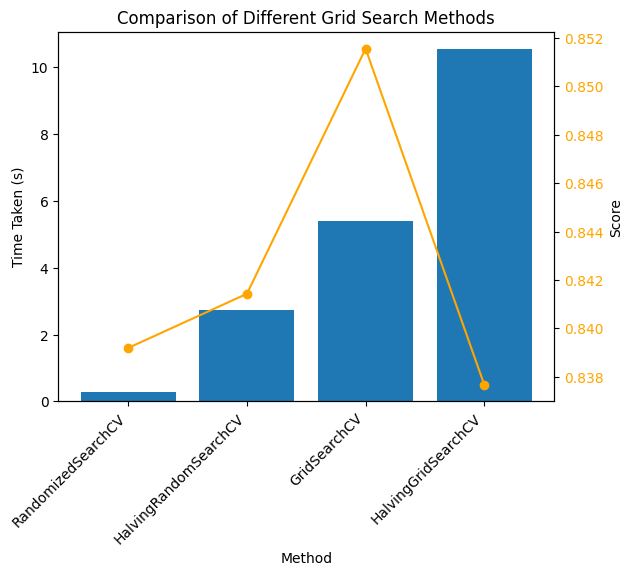

In [23]:
fig, ax1 = plt.subplots()
ax1.set_xlabel('Method')
ax1.set_ylabel('Time Taken (s)')
ax1.bar(results_df.index, results_df['time'])
ax1.tick_params(axis='y')

ax1.set_xticks(range(len(results_df.index)))
ax1.set_xticklabels(results_df.index, rotation=45, ha='right')

ax2 = ax1.twinx()  
ax2.set_ylabel('Score')
ax2.plot(results_df.index, results_df['score'], marker='o', linestyle='-', color='orange')
ax2.tick_params(axis='y', labelcolor='orange')

plt.title('Comparison of Different Grid Search Methods')
plt.show()